<a href="https://colab.research.google.com/github/Thujaina/ECG-classification----Res-Net/blob/main/symmetric_CE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D
from keras.layers import Add, Input
from keras.models import Model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

In [5]:
train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


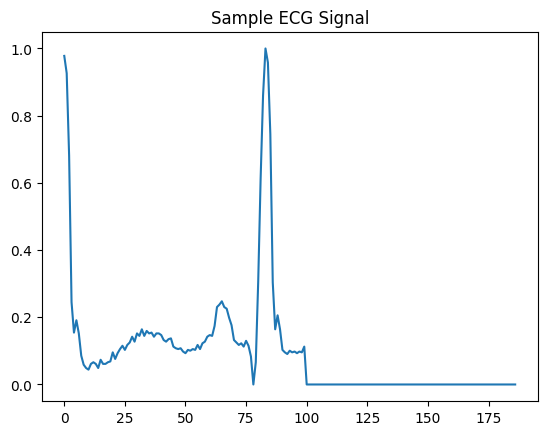

In [6]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

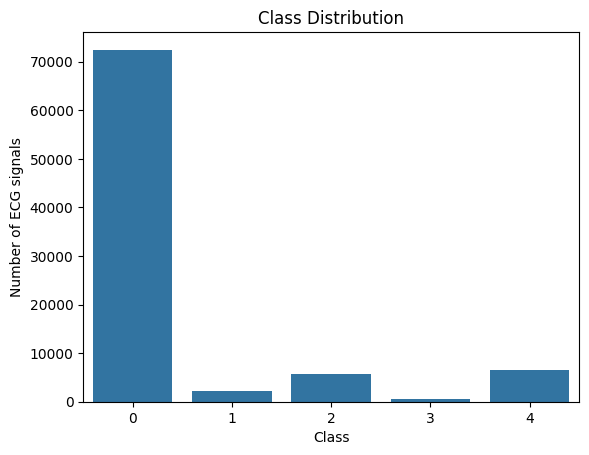

In [7]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")

plt.show()

In [8]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [20]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [21]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [22]:
print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [34]:
# Reduce dataset size for faster training (CPU-friendly)
X_res = X_res[:120000]
y_res = y_res[:120000]

In [35]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [36]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [37]:
X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [38]:
def symmetric_cross_entropy(alpha=0.1, beta=1.0):

    def loss(y_true, y_pred):

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        y_true = tf.cast(y_true, tf.float32)

        cce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        rce = -tf.reduce_sum(y_pred * tf.math.log(y_true + 1e-7), axis=-1)

        return alpha * cce + beta * rce

    return loss

In [39]:
def resnet_block(x, filters, stride=1):

    shortcut = x

    x = Conv1D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = Conv1D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)

    return x

In [40]:
def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32,3,activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x,64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x,256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128,activation='relu')(x)
    outputs = Dense(5,activation='softmax')(x)

    model = Model(inputs,outputs)

    model.compile(
        optimizer='adam',
        loss=symmetric_cross_entropy(alpha=0.1, beta=1.0),
        metrics=['accuracy']
    )

    return model

In [31]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []
X_res = np.array(X_res).reshape(-1,187,1)
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = resnet_ecg()

    model.fit(X_tr, y_tr, epochs=5, batch_size=64, verbose=1)

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)
print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1334s 351ms/step - accuracy: 0.9154 - loss: 1.4834
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1335s 349ms/step - accuracy: 0.9521 - loss: 0.8290
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1295s 343ms/step - accuracy: 0.9639 - loss: 0.6251
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1334s 341ms/step - accuracy: 0.9692 - loss: 0.5332
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1285s 340ms/step - accuracy: 0.9751 - loss: 0.4282

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1341s 345ms/step - accuracy: 0.9139 - loss: 1.5094
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1288s 341ms/step - accuracy: 0.9567 - loss: 0.7516
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1287s 341ms/step - accuracy: 0.9669 - loss: 0.5743
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1287s 341ms/step - accuracy: 0.9735 - loss: 0.4615
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1310s 347ms/step - accuracy: 0.9767 - loss: 0.4023

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 1319s 347ms/ste

In [43]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=128
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 559s 745ms/step - accuracy: 0.9120 - loss: 1.5343 - val_accuracy: 0.8979 - val_loss: 1.7729
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 559s 742ms/step - accuracy: 0.9365 - loss: 1.1000 - val_accuracy: 0.6837 - val_loss: 5.5843
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 554s 739ms/step - accuracy: 0.9438 - loss: 0.9707 - val_accuracy: 0.8961 - val_loss: 1.7816
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 558s 743ms/step - accuracy: 0.9491 - loss: 0.8740 - val_accuracy: 0.9171 - val_loss: 1.4207
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 565s 747ms/step - accuracy: 0.9554 - loss: 0.7679 - val_accuracy: 0.7766 - val_loss: 3.8424
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 540s 721ms/step - accuracy: 0.9606 - loss: 0.6844 - val_accuracy: 0.7717 - val_loss: 3.9214
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 540s 720ms/step - accuracy: 0.9638 - loss: 0.6298 - val_accuracy: 0.9622 - val_loss: 0.6514
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 563s 721ms/step - accuracy: 0.9674 -

In [44]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", mcc)

750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step
Validation MCC: 0.8611154752533308


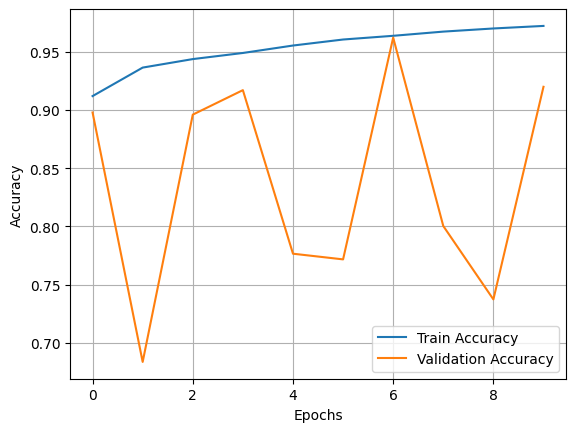

In [45]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [46]:
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

Final Training Accuracy: 0.9723
Final Validation Accuracy: 0.9200


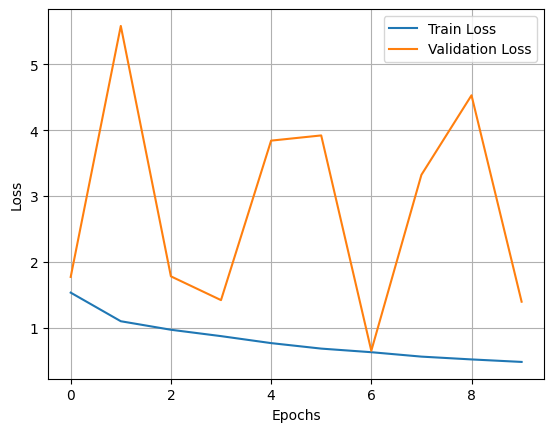

In [47]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [48]:
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

Final Training Loss: 0.4822
Final Validation Loss: 1.3966


In [50]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.7818
Test Accuracy: 0.8972


In [51]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.90      0.94     18118
         1.0       0.25      0.84      0.38       556
         2.0       0.89      0.89      0.89      1448
         3.0       0.97      0.42      0.59       162
         4.0       0.75      0.99      0.86      1608

    accuracy                           0.90     21892
   macro avg       0.77      0.81      0.73     21892
weighted avg       0.95      0.90      0.91     21892



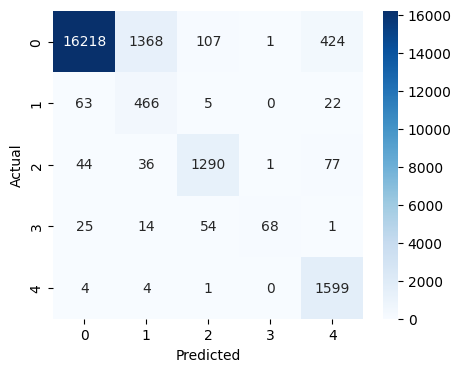

In [52]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [54]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

# Ensure correct shape
X_res = np.array(X_res).reshape(-1, 187, 1)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]

    # Convert to one-hot (since your ResNet uses softmax)
    y_tr = tf.keras.utils.to_categorical(y_res[train_idx], 5)
    y_va = tf.keras.utils.to_categorical(y_res[val_idx], 5)

    model = resnet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=128,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 438s 685ms/step - accuracy: 0.8578 - loss: 2.4813
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 420s 672ms/step - accuracy: 0.9157 - loss: 1.4678
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 441s 672ms/step - accuracy: 0.9369 - loss: 1.1011
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 444s 674ms/step - accuracy: 0.9401 - loss: 1.0401
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 419s 671ms/step - accuracy: 0.9479 - loss: 0.9026
Fold 1 Accuracy: 0.9160

Fold 2
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 431s 674ms/step - accuracy: 0.8621 - loss: 2.4082
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 443s 676ms/step - accuracy: 0.9272 - loss: 1.2680
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 447s 683ms/step - accuracy: 0.9388 - loss: 1.0572
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 441s 682ms/step - accuracy: 0.9477 - loss: 0.9076
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 436s 672ms/step - accuracy: 0.9526 - loss: 0.8204
Fold 2 Accuracy: 0.5231

Fold 3
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━